In [1]:
%load_ext autoreload
%autoreload 2

from pathlib import Path 
import os
os.environ['MUJOCO_GL'] = 'egl'
os.environ['MKL_SERVICE_FORCE_INTEL'] = '1'
from tqdm import tqdm
from IPython.display import Video

import torch
import numpy as np

import sys
sys.path.append("/mnt/home/focus")

os.chdir("/mnt/home/focus")
print(f"Working directory: {os.getcwd()}")

import env
from env.make import make

import matplotlib.pyplot as plt
import matplotlib.animation as animation

/opt/conda/lib/python3.11/site-packages/robosuite/__init__.py:7: DeprecationWarning: The 'warn' method is deprecated, use 'warning' instead
  ROBOSUITE_DEFAULT_LOGGER.warn("No private macro file found!")
[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/conda/lib/python3.11/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


Working directory: /mnt/home/focus


/opt/conda/lib/python3.11/site-packages/warp_maniskill/warp/codegen.py:13: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp
/opt/conda/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: DeprecationWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", DeprecationWarning)


In [2]:
# LOAD CONFIG FILE FOR EXPERIMENT
# to handle multilple config file, just load one of the latest config file and then duplicate for each env/agent modifying the necessary parameters

# from hydra import compose, initialize
# from omegaconf import OmegaConf

# initialize(config_path="../../../../public/projects/mazpie/online_reacher_benchmark_1/pretrain/318a11550ec6f5c89516b04dfc3756f2/code/exp_local/2024.03.12/175058_dreamer_reacher_hard_/.hydra", job_name="config")
# cfg = compose(config_name="config")

In [2]:
# load relevant models
from pathlib import Path
from collections import defaultdict

models = defaultdict(list)

benchmark2agent = {"1": "dreamer", "2": "skill_dreamer", "3": "dreamer", "4": "lexa", "5": "skill_focus"}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw"}

base_path = Path("/mnt/public/projects/mazpie/")
task = "CustomLift"
benchmarks = [f"offline_{task2domainbench[task]}_benchmark_{i}" for i in range(1,6)]

expl_dataset = "expl_focus"
vis_target = False
distance_modes = ["cosine", "temporal"]

snapshot = "snapshot_250000"
seeds = [1, 2, 3]

def load_agent(agent_path):
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    with agent_path.open('rb') as f:
        obj = torch.load(f, map_location=torch.device(device))
        agent = obj['agent']    
        step = obj['_global_step']
    return agent, step

def load(agent_path, device='cuda'):
    agent, step = load_agent(agent_path)
    # agent = init_agent(configs[task][id])
    agent.device = device
    agent.wm.device = device
    agent.wm.rssm.device = device
    agent.wm.rssm._cell.device = device
    agent.is_finetune = True
    agent.cfg.agent.only_expl_during_training = False
    # if id == "5":
    #     agent._shape_skill_latent = 32 * 48
    return agent
        
for benchmark in benchmarks: 
    for seed in seeds:
        benchmark_id = benchmark.split("_")[-1]
        path = Path(base_path) / benchmark / "pretrained_models" / benchmark2agent[benchmark_id] / task2domain[task] / task / str(seed) / expl_dataset
        if vis_target: path = path / "vis_target"
        if benchmark_id == "4": # in case of lexa  select the desired distance mode for testing
            for dist in distance_modes:
                path_lexa = path / dist
                path_lexa = path_lexa / f"{snapshot}.pt"
                models[f"{benchmark}_{dist}"].append(load(path_lexa))
                
        else:
            path = path / f"{snapshot}.pt"
            # load model from path
            models[benchmark].append(load(path))


In [44]:
from env.make import make

action_repeat = 2
eval_env = make(task2domain[task], task, action_repeat=action_repeat, seed=0, env_config=models[benchmarks[0]][0].cfg.env)

/opt/conda/lib/python3.11/site-packages/gym/spaces/box.py:128: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


In [5]:
models["offline_reacher_benchmark_4_temporal"][0].cfg.env

{'segmenter': {'fastSAM_url': 'https://huggingface.co/spaces/An-619/FastSAM/resolve/main/weights/FastSAM.pt', 'xmem_url': 'https://github.com/hkchengrex/XMem/releases/download/v1.0/XMem-s012.pth', 'GroundingDino_url': 'https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth', 'checkpoints_folder': '/mnt/home/focus/checkpoints', 'mode': 'None', 'text_prompt': 'None', 'box_prompt': [0, 0, 0, 0], 'iou': 0.9, 'conf': 0.4, 'output': './output/', 'randomcolor': True, 'better_quality': False, 'retina': True, 'withContours': True}, 'name': 'dmc', 'horizon': 1000, 'controller': 'OSC_POSE', 'renderer': {'fps': 30, 'size': [64, 64], 'camera': 'agentview2', 'depths': True, 'segmentation_level': 'element', 'seg_size': [480, 480], 'gt_segmentation': True}, 'reward_shaping': False, 'task_reward': 'lift', 'objects': {'rgba': [1, 0, 0, 1], 'minsize': 0.025, 'spawn_range': 0.01, 'random_placement': False, 'name': ''}, 'goal': {'x': 'None', 'y': 'None', '

In [3]:
import collections

def flatten_observation(observation, output_key='observations'):
  if not isinstance(observation, collections.abc.MutableMapping):
    raise ValueError('Can only flatten dict-like observations.')

  if isinstance(observation, collections.OrderedDict):
    keys = observation.keys()
  else:
    # Keep a consistent ordering for other mappings.
    keys = sorted(observation.keys())

  observation_arrays = [observation[key].ravel() for key in keys]
  return type(observation)([(output_key, np.concatenate(observation_arrays))])

def get_target_observation(goal_pose):
    
    eval_env.set_goal_state(goal_pose) 
    action = np.zeros_like(eval_env.act_space["action"].sample())   
    obs = eval_env.step(action)
    return obs

In [4]:
import utils

# Initialization
step = ep = total_reward = total_success = global_step = 0


In [5]:
import math 
l = 0.12
def inverse_kinematic_double_pendulum(target):
    x, y = target
    try:
        q_2 = math.acos((x**2 + y**2 - 2*l**2) / (2*l**2))
        q_1 = math.atan2(y, x) - math.atan2(l*math.sin(q_2), l + l*math.cos(q_2))
        return (q_1, q_2)
    except:
        return None # in case computation is not possible
    
eval_env.set_goals_for_task()
fix_goals = eval_env.get_goals()
for goal in fix_goals:
    print(f"computed: {inverse_kinematic_double_pendulum(goal[1])}, expected: {goal[0]}")

NameError: name 'eval_env' is not defined

limits area:  [[-0.25, -0.25, 0], [0.25, 0.25, 0.1]]
[-0.25, -0.25, 0.05]
[-0.25, -0.125, 0.05]
[-0.25, 0.0, 0.05]
[-0.25, 0.125, 0.05]
[-0.25, 0.25, 0.05]
[-0.125, -0.25, 0.05]
[-0.125, -0.125, 0.05]
[-0.125, 0.0, 0.05]
[-0.125, 0.125, 0.05]
[-0.125, 0.25, 0.05]
[0.0, -0.25, 0.05]
[0.0, -0.125, 0.05]
[0.0, 0.0, 0.05]
[0.0, 0.125, 0.05]
[0.0, 0.25, 0.05]
[0.125, -0.25, 0.05]
[0.125, -0.125, 0.05]
[0.125, 0.0, 0.05]
[0.125, 0.125, 0.05]
[0.125, 0.25, 0.05]
[0.25, -0.25, 0.05]
[0.25, -0.125, 0.05]
[0.25, 0.0, 0.05]
[0.25, 0.125, 0.05]
[0.25, 0.25, 0.05]
[      -0.25       -0.25        0.05]
[      -0.25      -0.125        0.05]
[      -0.25           0        0.05]
[      -0.25       0.125        0.05]
[      -0.25        0.25        0.05]
[     -0.125       -0.25        0.05]
[     -0.125      -0.125        0.05]
[     -0.125           0        0.05]
[     -0.125       0.125        0.05]
[     -0.125        0.25        0.05]
[          0       -0.25        0.05]
[          0      -0.125

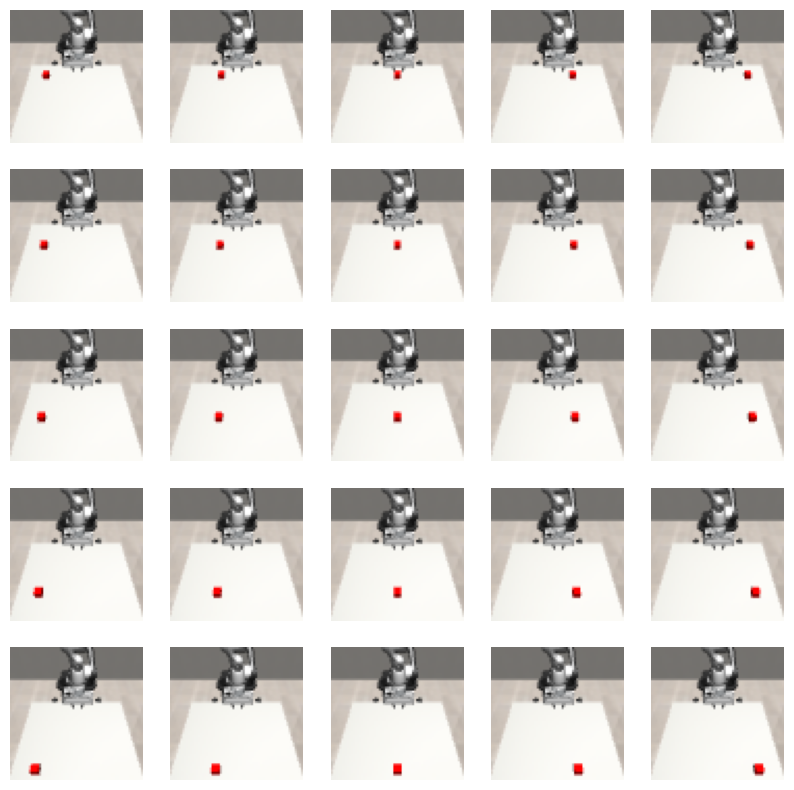

In [89]:

# get evaluation points set uniformelly distributed over the entire exploration space
eval_env.reset()

class Grid:
    def __init__(self, size):
        self.grid = np.empty((size, size), dtype=object) 
        self.num_valid_values = 0
        
    def __getitem__(self, index: list):
        return self.grid[index[0]][index[1]]
    
    def __setitem__(self, index: list, value):
        if value is None:
            raise ValueError("Value cannot be None")
        
        if self.grid[index[0]][index[1]] is not None:
             self.grid[index[0]][index[1]].append(value)
        else:
            if isinstance(value, list):
                self.grid[index[0]][index[1]] = value
            else:
                self.grid[index[0]][index[1]] = [value]
        self.num_valid_values += 1
        
    def get_all_values(self):
        return np.array([x for x in self.grid.flatten() if x is not None]).flatten()
    
    def get_stats_over_grid_elements(self):
        means = np.zeros_like(self.grid)
        std = np.zeros_like(self.grid)
        
        for iy, ix in np.ndindex(self.grid.shape):
            if self.grid[iy, ix] is not None:
                means[iy, ix] = np.mean(self.grid[iy, ix])
                std[iy, ix] = np.std(self.grid[iy, ix])                
        return means, std

    @property
    def shape(self):
        return self.grid.shape
    
eval_points = []
num_pt = 5
limits_expl_area = eval_env.limits_exploration_area
print("limits area: ", limits_expl_area)
points = np.linspace(limits_expl_area[0][:2], limits_expl_area[1][:2], num=num_pt, axis=1)

# concatenate over all possible combinations of points, to create a grid of points
eval_poses = []
import itertools
for t in itertools.product(*points):
    if "reacher" not in task: # 3d envs
        t = list(t)
        t.append(0.05)
        print(t) 
    eval_poses.append(list(t))


#visualize the target poses over a plot grid
eval_poses = np.array(eval_poses)
fig, axs = plt.subplots(num_pt, num_pt, figsize=(2 * num_pt, 2 * num_pt))

for ax in axs.flatten():
    ax.axis('off')
    
valid_targets = Grid(num_pt)
for i, pose in enumerate(eval_poses):
    x = i // num_pt
    y = i % num_pt
    ax = axs[x, y]
    
    # in case of reacher the target pose of the arm needs to be set since the object is the eef
    if "reacher" in task: 
        target = (inverse_kinematic_double_pendulum(eval_poses[i]), eval_poses[i])
        if not target[0] or (list(target[1]) == [0.0, 0.0]): # in case of target not reacheable skip the episode + target pos is [0 ,0] that would null the metrics
            continue
        else:
            valid_targets[x, y] = list(target)
    else:
        print(eval_poses[i])
        target = [eval_poses[i], eval_poses[i]]
        valid_targets[x, y] = target
    
    # set target before reset of env
    eval_env.set_target(target[1])                    
    target_obs = get_target_observation(target[0])  
    ax.imshow(target_obs["rgb"].transpose(1,2,0))
    
print("num valid targets: ", valid_targets.num_valid_values)
    

In [6]:
def grid_visualization_metrics(metric: Grid):
    """
        Takes in one metric, organized by grid and plot it over a colormap (average over seeds) 
    """    
    h, w = metric.shape
    plt.imshow(metric.grid, cmap='viridis')

NameError: name 'Grid' is not defined

In [93]:
import imageio
if "video" in locals(): del video  # in case it is defined

save_files = True 
eval_benchmark = "offline_rs_benchmark_5"
eval_env.visualize_target = vis_target
cfg = models[eval_benchmark][0].cfg

valid_episodes = 0
target_skill_inputs = ["pos"]
seeds = len(models[eval_benchmark])

move_to_target_metrics = {}
for target_skill_input in target_skill_inputs:
    move_to_target_metrics[target_skill_input] = {}

vis_target_dir = lambda s: "vis_target_" if s else ""
save_dir = Path(f"notebooks/focus++ evaluations/target_reach_evaluations/{task2domain[task]}/{task}/{vis_target_dir(vis_target)}")

if not os.path.exists(save_dir):
    os.makedirs(save_dir)

for target_skill_input in target_skill_inputs:
    for s, agent in enumerate(tqdm(models[eval_benchmark])):
        if "video" in locals(): del video
        obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
        meta = agent.init_meta
        
        for iy, ix in tqdm(np.ndindex(valid_targets.shape)):
            episode_data = []
            eval_env.reset()
            
            # set goal from the equaly distributed set of points 
            target = valid_targets[iy, ix]
            if not target: # in case of target not reacheable skip the episode
                continue
            
            # set target before reset of env
            eval_env.set_target(target[1])                    
            if agent.name == "lexa":
                target_obs = get_target_observation(eval_env, target[0])  
                target = {k: torch.as_tensor(np.copy(v), device="cuda:0").unsqueeze(0).unsqueeze(0) for k, v in target_obs.items()} # add batch size and length dimensions
                agent.set_target(target) 
            else:
                agent.set_target(target[1]) 
                
            # set target before reset of env
            # eval_env.set_target(target[1])                    
            # agent.set_target(target[1]) 
            # target_obs = get_target_observation(target[0])  
            
            # plt.imshow(target_obs["rgb"].transpose(1,2,0))
            # plt.show()
            
            # tensor_target_obs = {
            #     k: torch.as_tensor(np.copy(v), device=agent.device).unsqueeze(0)
            #     for k, v in target_obs.items()
            # }
            # embed = agent.wm.encoder(agent.wm.preprocess(tensor_target_obs))
            
            # warmup_cycles = 1
            # latent = agent.wm.rssm.initial(len([target_obs["reward"]]))
            
            # for i in range(warmup_cycles):
            #     latent, _ = agent.wm.rssm.obs_step(
            #         latent,
            #         tensor_target_obs["action"],
            #         embed,
            #         tensor_target_obs["is_first"],
            #         should_sample=True
            #         )
                
            # f_i = agent.wm.rssm.get_feat(latent).unsqueeze(0)
            # if target_skill_input == "obs":
            #     if agent.name == "skill_focus":
            #         target_skill = agent.wm.heads["object_decoder"].object_latent_extractor(f_i.detach())["post"]["mean"][0,0,0,:].unsqueeze(0)
            #     elif agent.name == "lexa":
            #         target_skill = f_i[0]
                    
            # elif target_skill_input == "pos":
            #     target_skill = agent.wm.object_encoder(torch.tensor([[[target[1]]]], device="cuda", dtype=torch.float))["prior"]["mean"][0][0]
            
            obs = eval_env.reset()
            eval_env.set_target(target[1])                    

            # double for visualization purposes
            obs["eval_rgb"] = obs["rgb"]
            
            episode_data.append(obs)
            agent_state = None
            
            while not bool(obs["is_last"]):
                with torch.no_grad(), utils.eval_mode(agent):
                    action, agent_state = agent.act(
                        obs,
                        meta,
                        global_step,
                        eval_mode=True,
                        state=agent_state,
                        # target_skill=target_skill
                    )
                obs = eval_env.step(action)
                
                # in case of dmc manipulator environment, the target position needs to update at every step, given the internal machanics
                if cfg.agent.train_target_reach:
                    obs["eval_rgb"] = eval_env.get_rgb_with_target()
                else:
                    obs["eval_rgb"] = obs["rgb"]

                episode_data.append(obs)
                total_reward += obs["reward"]
                step += 1
                obj_pos = np.concatenate((obj_pos, [obs["objects_pos"][0]]))

            valid_episodes += 1
            
            # log moving average, move to target metrics
            if cfg.agent.train_target_reach:
                target_pos = agent._target_pos.cpu().numpy()
                episode_metrics = utils.move_to_target_metrics(obj_pos, target_pos)
                if not bool(move_to_target_metrics[target_skill_input]): # check if dict is empty
                    move_to_target_metrics[target_skill_input] = {k: Grid(num_pt) for k in episode_metrics.keys()} # instantiate grid for each metric
                
                for k, v in episode_metrics.items():
                    move_to_target_metrics[target_skill_input][k][iy, ix] = v
                
                # print(target)
                # print(episode_metrics)
                
            # video output for visualization                 
            if save_files:
                if "video" not in locals():
                    video = np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)    
                else:
                    video = np.concatenate([video, np.expand_dims(np.stack([obs['eval_rgb'] for obs in episode_data], axis=0), axis=0)], axis=-1)    
                
            total_success += obs["success"]
            obj_pos = np.zeros_like([cfg.env.object_start_pos]).astype(float) 
        
        if save_files:
            imageio.mimwrite(save_dir / f'{task}_{vis_target_dir(vis_target)}eval_{s}_{eval_benchmark}.mp4', video[0].transpose(0,2,3,1), fps=15) 

  0%|          | 0/3 [00:00<?, ?it/s]

25it [04:32, 10.90s/it]
25it [04:33, 10.93s/it]4:33<09:06, 273.42s/it]
25it [04:38, 11.14s/it]9:07<04:33, 273.84s/it]
100%|██████████| 3/3 [13:47<00:00, 275.69s/it]


Modality pos move_to_target_final: 0.627709521074455 ± 0.11848893402148637
Modality pos move_to_target_min: 0.6975103058864952 ± 0.12764304012416292
Modality pos move_to_target_max: 0.35173290336047486 ± 0.026885925423546654
Modality pos move_to_target_mean: 0.5939789348620556 ± 0.0946536340166536


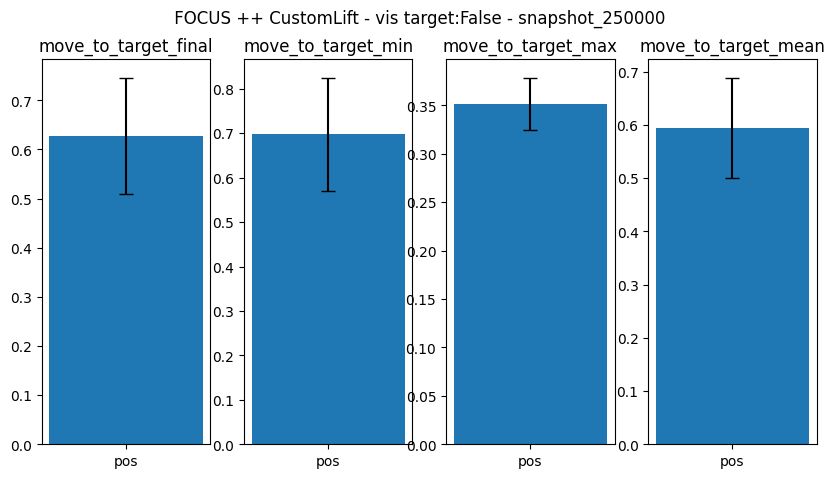

In [94]:
save_files = True

# cummulative metrics over all seeds and positions 
n_metrics = len(move_to_target_metrics["pos"].keys())
fig, axs = plt.subplots(1, n_metrics, figsize=(10, 5))
for i, metric in enumerate(move_to_target_metrics["pos"].keys()):
    for mod in move_to_target_metrics.keys():
        mean = np.mean(move_to_target_metrics[mod][metric].get_all_values())
        std = np.std(move_to_target_metrics[mod][metric].get_all_values())
        print(f"Modality {mod} {metric}: {mean} ± {std}")

        axs[i].bar(mod, mean, yerr=std, capsize=5, label=metric)
        axs[i].set_title(metric)
        
fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

if save_files:
    plt.savefig(save_dir / f'{task}_{vis_target_dir(vis_target)}_{eval_benchmark}.png')


In [95]:
metric = list(move_to_target_metrics[mod].keys())[0]

a = np.zeros_like(move_to_target_metrics[mod][metric].grid)
print(a)

for iy, ix in np.ndindex(move_to_target_metrics[mod][metric].shape):
    if move_to_target_metrics[mod][metric][iy, ix] is not None:
        a[iy, ix] = np.mean(move_to_target_metrics[mod][metric][iy, ix])

print(a)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]
[[0.5794800700757174 0.6270282043010359 0.6612716096867751 0.6872162829717822 0.6162735259339298]
 [0.5905534543126848 0.6347673278279874 0.7265579384542721 0.6608725869062514 0.6429244265413473]
 [0.5448013514743919 0.5333540005930058 0.3873089443644469 0.7128669261321617 0.6740087988557351]
 [0.5951477249963771 0.6373308484665445 0.6689264394175863 0.6999390936362152 0.662119382817297]
 [0.5891284583443045 0.6480473185067278 0.7414925072332054 0.67376173941039 0.4975590656012036]]


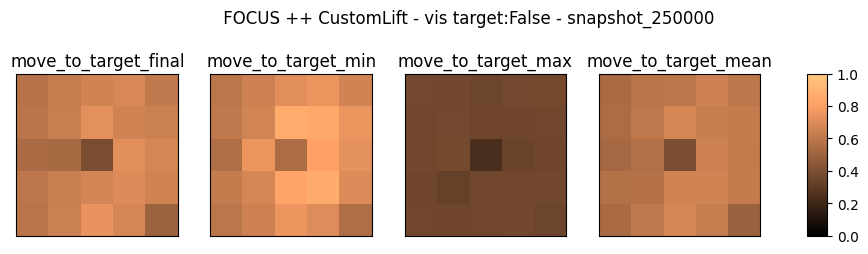

In [96]:
save_files = True

# cummulative metrics over all seeds and positions 
n_metrics = len(move_to_target_metrics["pos"].keys())
fig, axs = plt.subplots(1, n_metrics, figsize=(12, 3))
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    
mod = "pos"
for i, metric in enumerate(move_to_target_metrics[mod].keys()):
    im = axs[i].imshow(move_to_target_metrics[mod][metric].get_stats_over_grid_elements()[0].astype(float), cmap='copper', vmin=0, vmax=1)
    axs[i].set_title(metric)
        
fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

# visualize legend for plots
fig.colorbar(im, ax=axs.ravel().tolist(), shrink=0.7, aspect=8)


if save_files:
    plt.savefig(save_dir / f'colormap_{task}_{vis_target_dir(vis_target)}_{eval_benchmark}.png')


KeyboardInterrupt: 

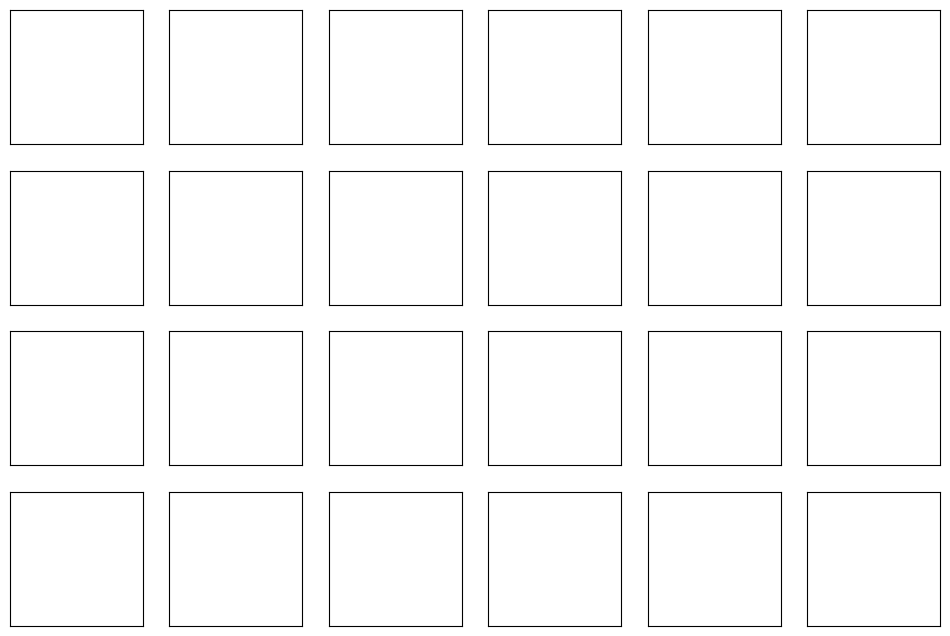

In [17]:
# Load the results from deployed experiments and plot them in the map
import numpy as np
from pathlib import Path
import os
import evals

results_path = Path("/mnt/public/projects/mazpie/target_metrics/eval_results")

benchmark2agent = {"1": "dreamer", "2": "Dreamer w/ PCP", "3": "Dreamer", "4_cosine": "LEXA (cosine)", "4_temporal": "LEXA (temporal)", "5": "FOCUS w/ LCP", "7": "FOCUS"}
IDorder = {"1":0, "2":2, "3": 0, "4_cosine":3, "4_temporal":4, "5":5, "7":1}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
tasks2label = {"reacher_easy": "Reacher", "CustomLift": "Cube move", "shelf-place": "Shelf place", "bin-picking": "Pick&Place"}

tasks = ["reacher_easy", "CustomLift", "shelf-place", "bin-picking"] 
metric = "move_to_target_mean"
# metric = "final_distance_to_target"


n_tasks = len(tasks)
n_models = 6
fig, axs = plt.subplots(n_tasks, n_models, figsize=(n_models*2, n_tasks*2))
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])
    

for j, task in enumerate(tasks):
    domain = task2domain[task]
    exp_path = results_path / f"{domain}/{task}"

    models_path = [x[0] for x in os.walk(exp_path)][1:]
    models_path.sort()
    
    for i, model_path in enumerate(models_path):
        # load the relative npy file
        model_path = Path(model_path)
        benchmark = model_path.name
        try:
            eval_results = np.load(model_path / f"{task}_eval.npy", allow_pickle=True)
            eval_result_metric = eval_results.item()[metric]    
        except:
            print(f"{model_path} not found, skipping")
            continue
        
        # print(f"{benchmark2agent[model_path.name]}: {eval_result_metric.get_stats_over_grid_elements()[0].astype(float)}")
        mean = np.mean(eval_result_metric.get_all_values())
        std = np.std(eval_result_metric.get_all_values())
        print(f"{task}: {mean} ± {std}")

        im = axs[j, IDorder[benchmark]].imshow(eval_result_metric.get_stats_over_grid_elements()[0].astype(float), cmap='magma', vmin=0, vmax=1)
        
        if j == 0:
            axs[j, IDorder[benchmark]].set_title(benchmark2agent[model_path.name])
        if i == 0:
            # set y_label
            axs[j, IDorder[benchmark]].set_ylabel(tasks2label[task], fontsize=14)

# fig.suptitle(metric)
# visualize legend for plots
cbar_ax = fig.add_axes([0.925, 0.3, 0.02, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.tick_params(labelsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.1)
plt.savefig(f"notebooks/focus++ evaluations/{metric}_map_all_tasks.png",  bbox_inches='tight', dpi=800) 

reacher_easy | 1: 0.2592938215768412 ± 0.1144884499981542
reacher_easy | 2: 0.8007012333563993 ± 0.08336058931516692
reacher_easy | 3: 0.26792903412478486 ± 0.10980642156456515
reacher_easy | 5: 0.9122306203270563 ± 0.029855168464910816
reacher_easy | 7: 0.2896076789849057 ± 0.10983823427598982
reacher_easy | 8: 0.8730765413374665 ± 0.046800924770965965
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_ not found, skipping
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_/1 not found, skipping
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_/2 not found, skipping
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_/3 not found, skipping
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_/5 not found, skipping
/mnt/public/projects/mazpie/target_metrics/eval_results/dmc/reacher_easy/vis_target_/7 not found, skipping
Cust

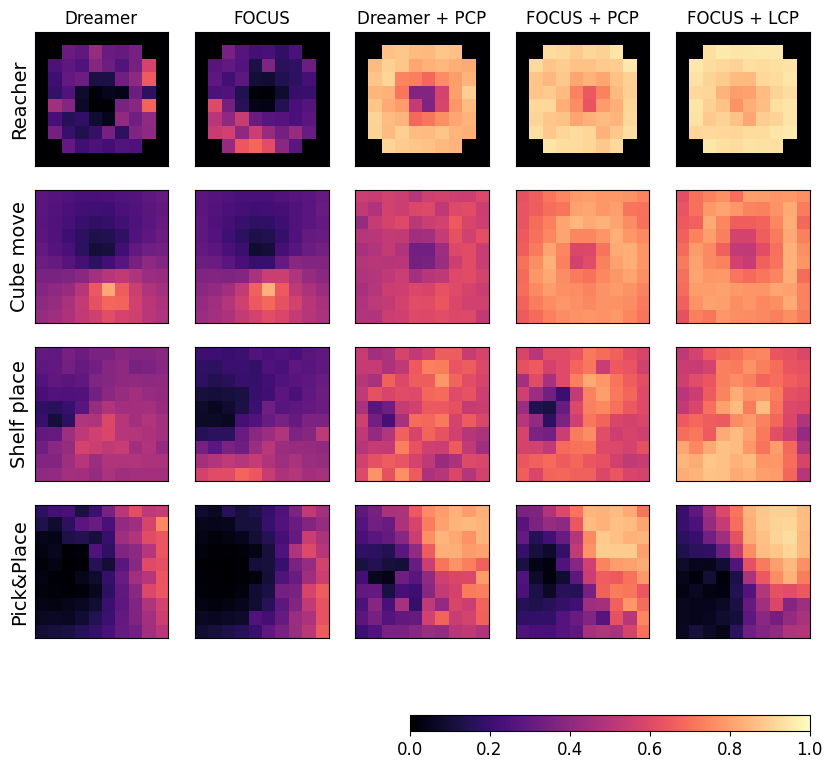

In [2]:
# Load the results from deployed experiments and plot them in the map
import numpy as np
from pathlib import Path
import os
import evals
from scipy import stats

results_path = Path("/mnt/public/projects/mazpie/target_metrics/eval_results")

benchmark2agent = {"1": "dreamer", "2": "Dreamer + PCP", "3": "Dreamer", "5": "FOCUS + LCP", "7": "FOCUS", "8": "FOCUS + PCP"}
IDorder = {"1":0, "2":2, "3": 0, "5":4, "7":1, "8":3}
task2domain = {"reacher_easy": "dmc", "reacher_hard": "dmc", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
task2domainbench = {"reacher_easy": "reacher", "reacher_hard": "reacher", "CustomLift": "rs", "shelf-place": "mw", "bin-picking": "mw"}
tasks2label = {"reacher_easy": "Reacher", "CustomLift": "Cube move", "shelf-place": "Shelf place", "bin-picking": "Pick&Place"}

tasks = ["reacher_easy", "CustomLift", "shelf-place", "bin-picking"] 
metric = "move_to_target_mean"
# metric = "final_distance_to_target"
skip_benchmarks = ["4_cosine", "4_temporal"]

n_tasks = len(tasks)
n_models = 5
fig, axs = plt.subplots(n_tasks, n_models, figsize=(n_models*2, n_tasks*2))
for ax in axs.flatten():
    ax.set_xticks([])
    ax.set_yticks([])

overall = {}
for j, id in enumerate(IDorder.keys()):
    overall[id] = {"mean": [], "std": []}
    
for j, task in enumerate(tasks):
    domain = task2domain[task]
    exp_path = results_path / f"{domain}/{task}"

    models_path = [x[0] for x in os.walk(exp_path)][1:]
    models_path.sort()
    
    for i, model_path in enumerate(models_path):
        # load the relative npy file
        model_path = Path(model_path)
        benchmark = model_path.name
        if benchmark in skip_benchmarks:
            continue
        try:
            eval_results = np.load(model_path / f"{task}_eval.npy", allow_pickle=True)
            eval_result_metric = eval_results.item()[metric]    
        except:
            print(f"{model_path} not found, skipping")
            continue
        
        # print(f"{benchmark2agent[model_path.name]}: {eval_result_metric.get_stats_over_grid_elements()[0].astype(float)}")
        mean = np.mean(eval_result_metric.get_all_values())
        std = np.std(eval_result_metric.get_all_values()) / np.sqrt(3)
        # std = stats.sem(eval_result_metric.get_all_values())
        
        overall[benchmark]["mean"] += [mean]
        overall[benchmark]["std"] += [std]
        
        print(f"{task} | {benchmark}: {mean} ± {std}")

        im = axs[j, IDorder[benchmark]].imshow(eval_result_metric.get_stats_over_grid_elements()[0].astype(float), cmap='magma', vmin=0, vmax=1)
        
        if j == 0:
            axs[j, IDorder[benchmark]].set_title(benchmark2agent[model_path.name])
        if i == 0:
            # set y_label
            axs[j, IDorder[benchmark]].set_ylabel(tasks2label[task], fontsize=14)

for j, id in enumerate(IDorder.keys()):
    mean = np.mean(overall[id]["mean"])
    std = np.mean(overall[id]["std"])
    print(f"{benchmark2agent[id]}: {mean} ± {std}")

# fig.suptitle(metric)
# visualize legend for plots
cbar_ax = fig.add_axes([0.5, 0, 0.4, 0.02])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.ax.tick_params(labelsize=12)
plt.subplots_adjust(wspace=0.2, hspace=0.1)
plt.savefig(f"notebooks/focus++ evaluations/{metric}_map_all_tasks.png",  bbox_inches='tight', dpi=800) 

dreamer: [[    0.38434     0.40818     0.36886     0.40368     0.36664     0.37627     0.38916     0.39053     0.38977      0.3721]
 [    0.37409     0.38248     0.38848     0.42964     0.35345     0.44966     0.41418     0.38708      0.3493     0.42109]
 [    0.37541     0.38499     0.38094     0.42356     0.39225     0.37647     0.53956     0.38705     0.43374     0.42248]
 [     0.3738     0.37903     0.33884       0.397     0.36179     0.51284      0.4987     0.38561     0.45281     0.45411]
 [    0.37341     0.33541     0.38947     0.37736     0.55136      0.5126     0.45777       0.419     0.40446     0.39291]
 [    0.36611     0.35853      0.3801     0.31069     0.43914     0.37753     0.28118     0.40508     0.36758     0.37383]
 [    0.35584     0.41156     0.40652     0.33272     0.34664     0.31205     0.31587     0.31018     0.38033     0.37172]
 [    0.35028     0.35667     0.35338     0.42005     0.32267     0.40358     0.34662     0.38253     0.37109     0.35771]
 [    0

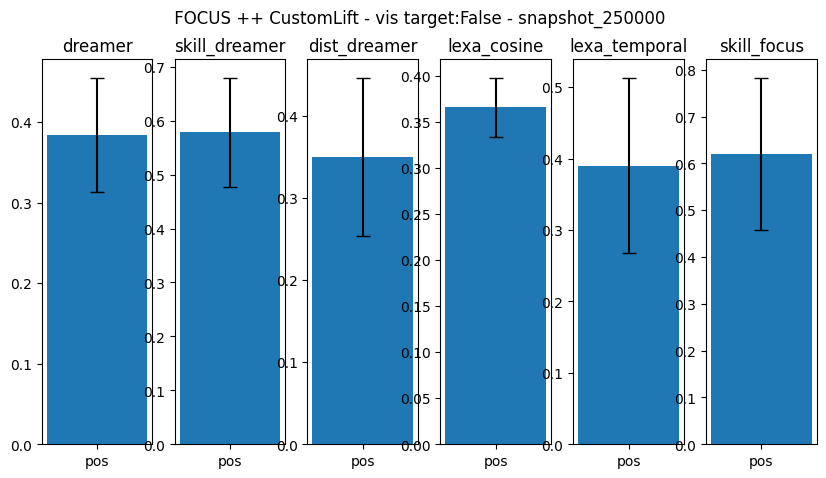

In [101]:
fig, axs = plt.subplots(1, n_models, figsize=(10, 5))

for i, model_path in enumerate(models_path):
        model_path = Path(model_path)
        try:
                eval_results = np.load(model_path / f"{task}_eval.npy", allow_pickle=True)
        except:
                print(f"{model_path} not found, skipping")
                continue
        axs[i].set_title(benchmark2agent[model_path.name])
        
        eval_result_metric = eval_results.item()[metric]    
        print(f"{benchmark2agent[model_path.name]}: {eval_result_metric.get_stats_over_grid_elements()[0].astype(float)}")
        
        mean = np.mean(eval_result_metric.get_all_values())
        std = np.std(eval_result_metric.get_all_values())
        print(f"Modality {mod} {metric}: {mean} ± {std}")

        axs[i].bar(mod, mean, yerr=std, capsize=5, label=metric)
        
fig.suptitle(f" FOCUS ++ {task} - vis target:{vis_target} - {snapshot}")
vis_target_dir = lambda s: "vis_target_" if s else ""

if save_files:
    plt.savefig(save_dir / f'{task}_{vis_target_dir(vis_target)}_{eval_benchmark}.png')

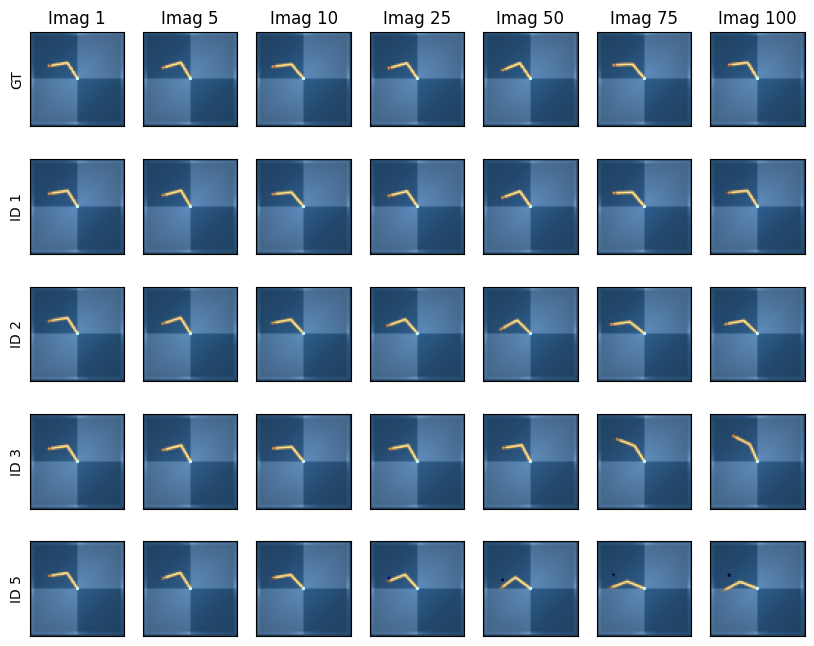

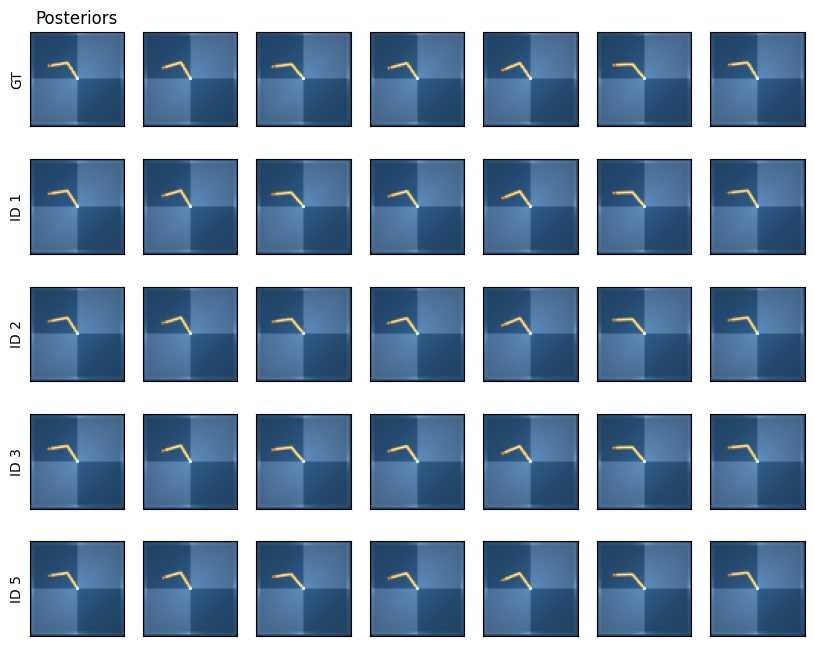

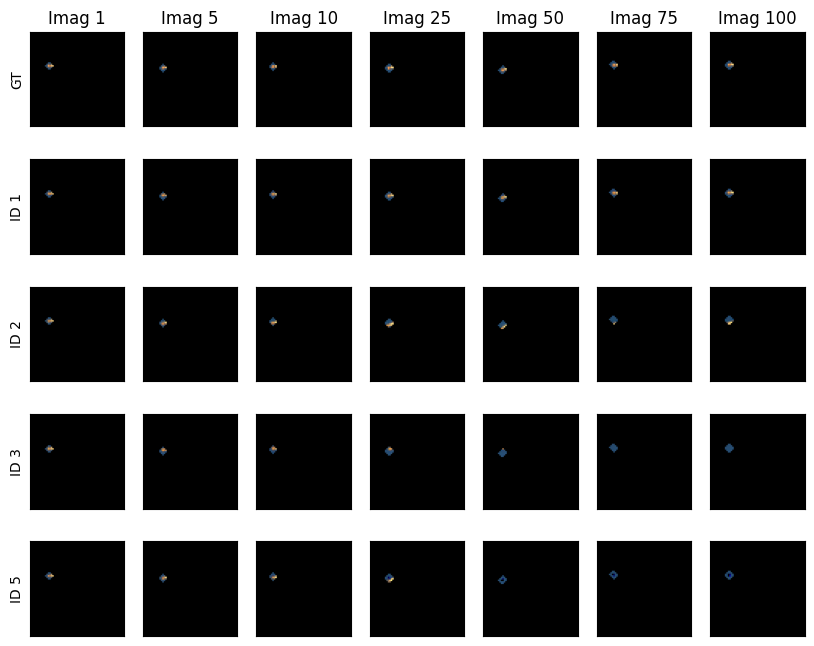

In [55]:
fig1, axs1 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig2, axs2 = plt.subplots(5, len(error_steps), figsize=(10, 8))
fig3, axs3 = plt.subplots(5, len(error_steps), figsize=(10, 8))


axs1[0, 0].set_ylabel(f"GT")
axs2[0, 0].set_ylabel(f"GT")
axs3[0, 0].set_ylabel(f"GT")


for i, id in enumerate(runs[task].keys()):
    axs1[i+1, 0].set_ylabel(f"ID {id}")
    axs2[i+1, 0].set_ylabel(f"ID {id}")
    axs3[i+1, 0].set_ylabel(f"ID {id}")
    

for i, s in enumerate(error_steps):
    axs1[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs1[0, i].set_title(f"Imag {s}")
    axs1[0, i].set_xticks([])
    axs1[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs1[y+1, i].imshow(det(prior_recons[task][id][0, s-1].permute(1,2,0)))
        axs1[y+1, i].set_xticks([])
        axs1[y+1, i].set_yticks([])

        
    axs2[0, i].imshow(det(truth[0, imag_start_step + s].permute(1,2,0)))
    axs2[0, 0].set_title(f"Posteriors")
    axs2[0, i].set_xticks([])
    axs2[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs2[y+1, i].imshow(det(post_recons[task][id][0, imag_start_step + s].permute(1,2,0)))
        axs2[y+1, i].set_xticks([])
        axs2[y+1, i].set_yticks([])

    axs3[0, i].imshow((truth_masked[0, imag_start_step + s].transpose(1,2,0)))
    axs3[0, i].set_xticks([])
    axs3[0, i].set_yticks([])
    
    for y, id in enumerate(runs[task].keys()):
        axs3[y+1, i].imshow(prior_recons_masked[task][id][0, s-1].transpose(1,2,0))
        axs3[0, i].set_title(f"Imag {s}")
        axs3[y+1, i].set_xticks([])
        axs3[y+1, i].set_yticks([])


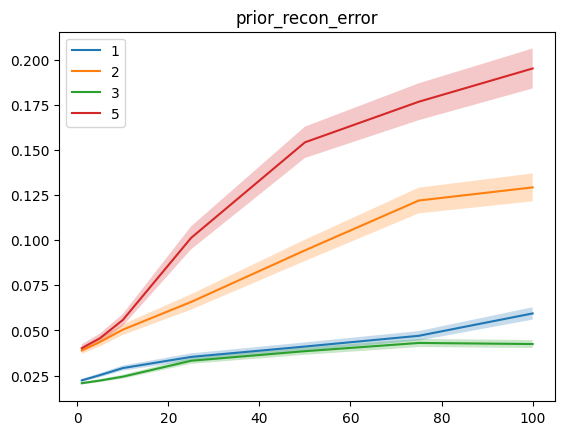

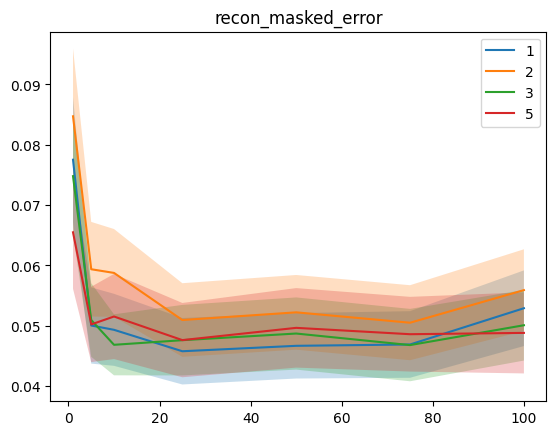

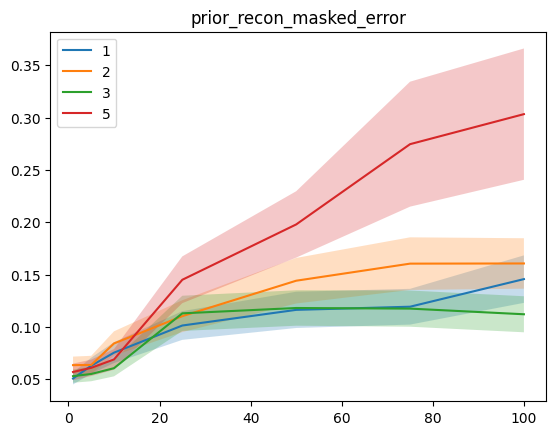

In [56]:
# for each img steps get a single mean value (with all the episodes)

# means = {}
# stds = {}

# for k, v in metrics.items():
#     means[k] = []
#     stds[k] = []
#     for i in range(len(v)):
#         means[k].append(np.array([x["mean"] for x in v[i]]).mean())
#         stds[k].append(np.array([x["std"] for x in v[i]]).mean())
        
plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_error"]]    

    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_error")
    
# plt.plot(error_steps, means["prior_recon_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_error"], stds["prior_recon_error"]), np.add(means["prior_recon_error"], stds["prior_recon_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["recon_masked_error"], stds["recon_masked_error"]), np.add(means["recon_masked_error"], stds["recon_masked_error"]), alpha=0.8)

plt.figure()
for id in runs[task].keys():
    
    means = [x[id][0]["mean"] for x in metrics["prior_recon_masked_error"]]
    stds = [x[id][0]["std"] for x in metrics["prior_recon_masked_error"]]
    # print(means)
    # print(stds)
    
    plt.plot(error_steps, means, label=id)
    plt.fill_between(error_steps, np.subtract(means, stds), np.add(means, stds), alpha=0.25)
    plt.legend()
    plt.title("prior_recon_masked_error")
    
# plt.figure()
# plt.plot(error_steps, means["prior_recon_masked_error"])
# plt.fill_between(error_steps, np.subtract(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), np.add(means["prior_recon_masked_error"], stds["prior_recon_masked_error"]), alpha=0.8)
        

In [36]:
from scipy.ndimage import convolve
import numpy as np
from scipy.ndimage import measurements

field = [[1, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                       [1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
                       [1, 0, 1, 0, 1, 1, 1, 0, 1, 0],
                       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                       [0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
                       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                       [0, 0, 0, 1, 0, 0, 0, 0, 0, 0],]

field = np.array(field)
shipSize_number = {"4":1, "3":2, "2":3, "1":4}    
kernels = []

for size in shipSize_number.keys():
    size = int(size)
    kernels.append([[0,0,0]] + ([[0,1,0]] * size) + [[0,0,0]])
    kernels.append([[0] * (size + 2)] + [[0] + ([1] * (size)) + [0]] + [[0] * (size + 2)])

lw, num = measurements.label(field)
area = measurements.sum(field, lw, index=np.arange(lw.max() + 1))

print(area)


[[1 0 0 0 0 2 2 0 0 0]
 [1 0 3 0 0 0 0 0 4 0]
 [1 0 3 0 5 5 5 0 4 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 6 0]
 [0 0 0 0 7 7 7 0 0 0]
 [0 0 0 0 0 0 0 0 8 0]
 [0 0 0 9 0 0 0 0 0 0]]
9
[0. 4. 2. 2. 2. 3. 1. 3. 1. 1.]


/tmp/ipykernel_10053/4141312277.py:23: DeprecationWarning: Please use `label` from the `scipy.ndimage` namespace, the `scipy.ndimage.measurements` namespace is deprecated.
  lw, num = measurements.label(field)
/tmp/ipykernel_10053/4141312277.py:27: DeprecationWarning: Please use `sum` from the `scipy.ndimage` namespace, the `scipy.ndimage.measurements` namespace is deprecated.
  area = measurements.sum(field, lw, index=np.arange(lw.max() + 1))


In [32]:
print(kernels)

[[[0, 0, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 0, 0]], [[0, 0, 0, 0, 0, 0], [0, 1, 1, 1, 1, 0], [0, 0, 0, 0, 0, 0]], [[0, 0, 0], [0, 1, 0], [0, 1, 0], [0, 1, 0], [0, 0, 0]], [[0, 0, 0, 0, 0], [0, 1, 1, 1, 0], [0, 0, 0, 0, 0]], [[0, 0, 0], [0, 1, 0], [0, 1, 0], [0, 0, 0]], [[0, 0, 0, 0], [0, 1, 1, 0], [0, 0, 0, 0]], [[0, 0, 0], [0, 1, 0], [0, 0, 0]], [[0, 0, 0], [0, 1, 0], [0, 0, 0]]]
